# 02 — MSS@10 con juez LLM (similitud de **situación**)

Métrica **oficial del paper**: para cada consulta, un juez LLM (`gpt-4.1-mini`, temp 0) puntúa 1-5
la similitud semántico-funcional de los 10 vecinos (situación = turno + 2 de contexto). **MSS@10** =
promedio de `overall_similarity`. Retrieval **exacto** (FlatIP), **cross-dialogue**, 100 queries
(seed 142 = las 100 "originales" del paper). Reproduce el protocolo de `notebook_07` de ANN-UNSL.

Las puntuaciones ya calculadas viven en `results/llm_judgments/`. **Re-correr** la evaluación completa:
`python scripts/eval_mss_llm.py --corpus 1m --queries 100` (requiere `OPENAI_API_KEY` en `ANN-UNSL/.env`).

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd

JUDGE = Path("~/Documents/GitHub/doctorado-unsl/packages/conversational-ann/results/llm_judgments").expanduser()
order = ["estatico", "dinamico", "ema_alpha_0_6", "Contextual-AR", "Contextual-Bidi"]
nice = {"estatico": "Static", "dinamico": "Cumulativo", "ema_alpha_0_6": "EMA(α0.6)",
        "Contextual-AR": "Contextual-AR", "Contextual-Bidi": "Contextual-Bidi"}

rows = []
for v in order:
    recs = [json.loads(l) for l in (JUDGE / f"judgments_1m_{v}.jsonl").read_text().splitlines() if l.strip()]
    def m(k): return np.mean([np.mean([e[k] for e in r["evaluations"]]) for r in recs])
    per_q = [np.mean([e["overall_similarity"] for e in r["evaluations"]]) for r in recs]
    rows.append({"representación": nice[v], "n": len(per_q), "MSS@10": round(float(np.mean(per_q)), 3),
                 "sd": round(float(np.std(per_q)), 3), "sem": round(float(m("semantic_similarity")), 2),
                 "func": round(float(m("functional_similarity")), 2),
                 "memoria": round(float(m("memory_usefulness")), 2)})
tab = pd.DataFrame(rows).sort_values("MSS@10", ascending=False).reset_index(drop=True)
tab

,representación,n,MSS@10,sd,sem,func,memoria
0,EMA(α0.6),100,3.790,0.665,3.80,3.80,3.77
1,Cumulativo,100,3.765,0.636,3.80,3.78,3.75
2,Contextual-AR,100,3.630,0.671,3.63,3.67,3.63
3,Contextual-Bidi,100,3.582,0.685,3.58,3.63,3.59
4,Static,100,3.324,0.751,3.31,3.39,3.31


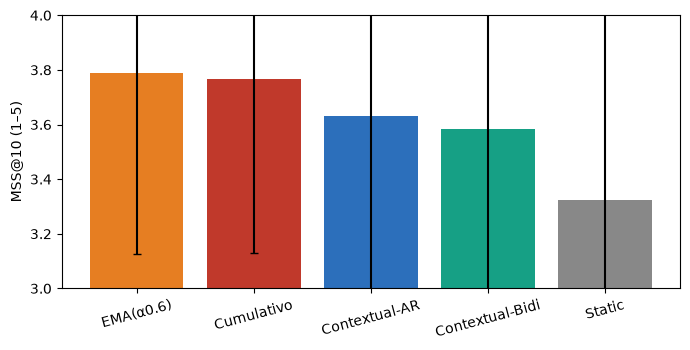

In [2]:
import matplotlib.pyplot as plt
colors = {"Static": "#888", "Cumulativo": "#c0392b", "EMA(α0.6)": "#e67e22",
          "Contextual-AR": "#2c6fbb", "Contextual-Bidi": "#16a085"}
p = tab.set_index("representación")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(p.index, p["MSS@10"], yerr=p["sd"], capsize=3, color=[colors[i] for i in p.index])
ax.set_ylabel("MSS@10 (1–5)"); ax.set_ylim(3, 4)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Reconciliación con el paper

El paper reporta MSS@10 sobre los **índices aproximados** (IVF/HNSW/IVFPQ); acá usamos **FlatIP
exacto**. Donde debe coincidir, coincide:

| | Paper (IVF / HNSW / IVFPQ) | Nuestro (FlatIP) |
|---|---|---|
| Static | 3.294 / 3.293 / 3.296 | **3.324** ✓ |
| EMA(α0.6) | 3.797 / 3.776 / 3.714 | **3.790** ✓ |
| Cumulativo | 3.665 / 3.661 / 3.647 | **3.765** (↑) |

El cumulativo nos da más alto porque la búsqueda exacta le da sus *mejores* vecinos → el gap
EMA−cumulativo se achica. **Parte de la ventaja del EMA en el paper es un efecto del índice
aproximado.** Que Static y EMA reproduzcan el paper valida el pipeline.

## Lectura honesta

- **Act-match (turno, nb01):** gana el contextual → *preserva* el acto.
- **MSS@10 (situación, este nb):** ganan los agregadores → *resumen* del estado.

Nuestro v1 (objetivo `next-turn`/`masked` + contrastivo, **zero-shot**) preserva la función del turno
pero **aún no calibra la geometría para similitud de situación**. **Próximo:** probing del estado +
estratificar por dependencia del contexto + (si se sostiene el claim de retrieval) un objetivo
contrastivo a nivel situación. Igualar el paper = HNSW/IVF/IVFPQ + 500 queries + Wilcoxon.